# 🛒 E-Commerce Recommendation System
## Task 2: BERT-Based Sentiment Analysis of Product Reviews

**Objective:** Classify Amazon product reviews into **Positive / Neutral / Negative** sentiments using a fine-tuned BERT model.

**Dataset:** Amazon Fine Food Reviews (via KaggleHub)

**Model:** `bert-base-uncased` from HuggingFace Transformers

---
### 📋 Notebook Structure
1. Install & Import Dependencies
2. Load Dataset
3. Data Preprocessing & Balancing
4. Tokenization & Dataset Preparation
5. Model Setup
6. Training
7. Evaluation
8. Inference Demo

## 1. 📦 Install & Import Dependencies

In [1]:
# Install required libraries
!pip install -q -U transformers datasets kagglehub scikit-learn

In [2]:
import transformers
print(transformers.__version__)
print(transformers.TrainingArguments)

5.7.0
<class 'transformers.training_args.TrainingArguments'>


In [4]:
import os
import numpy as np
import pandas as pd
import kagglehub
import warnings
warnings.filterwarnings('ignore')

from datasets import Dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, classification_report
import torch

# Confirm GPU is available
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU Device: Tesla T4


## 2. 📁 Load Dataset

In [5]:
# Download the Amazon Fine Food Reviews dataset via KaggleHub
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print(f"Dataset downloaded to: {path}")

# Load the CSV file
csv_path = os.path.join(path, "Reviews.csv")
df_raw = pd.read_csv(csv_path)

print(f"\nRaw dataset shape: {df_raw.shape}")
print(f"\nColumns: {df_raw.columns.tolist()}")
df_raw.head(3)

Dataset downloaded to: /kaggle/input/datasets/organizations/snap/amazon-fine-food-reviews

Raw dataset shape: (568454, 10)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...


## 3. 🧹 Data Preprocessing

Steps:
- Drop unnecessary columns
- Combine `Summary` + `Text` into a single `review` column
- Map `Score` → sentiment labels (0=Negative, 1=Neutral, 2=Positive)
- Balance the dataset (10k samples per class)

In [8]:
# ── Step 1: Drop unnecessary columns ──────────────────────────────────────────
cols_to_drop = [
    'Id', 'ProductId', 'UserId', 'ProfileName',
    'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Time'
]
df = df_raw.drop(columns=cols_to_drop)

print("Remaining columns:", df.columns.tolist())
print(f"Shape after dropping: {df.shape}")

Remaining columns: ['Score', 'Summary', 'Text']
Shape after dropping: (568454, 3)


In [9]:
# ── Step 2: Drop rows with missing values ─────────────────────────────────────
df = df.dropna(subset=['Score', 'Summary', 'Text'])
print(f"Shape after dropping NaNs: {df.shape}")

Shape after dropping NaNs: (568427, 3)


In [10]:
# ── Step 3: Combine Summary + Text into a single review column ─────────────────
df['review'] = df['Summary'].astype(str) + " " + df['Text'].astype(str)

print("Sample review:")
print(df['review'].iloc[0])

Sample review:
Good Quality Dog Food I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.


In [11]:
# ── Step 4: Map Score → Sentiment Label ───────────────────────────────────────
# Score 1,2  → 0 (Negative)
# Score 3    → 1 (Neutral)
# Score 4,5  → 2 (Positive)

def map_sentiment(score):
    if score in [1, 2]:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    else:         # 4 or 5
        return 2  # Positive

df['label'] = df['Score'].apply(map_sentiment)

# Keep only the columns we need
df = df[['review', 'label']]

print("Label distribution (before balancing):")
print(df['label'].value_counts())

Label distribution (before balancing):
label
2    443777
0     82012
1     42638
Name: count, dtype: int64


In [12]:
# ── Step 5: Balance the dataset ───────────────────────────────────────────────
# The dataset is heavily skewed toward Positive reviews.
# We sample 10,000 rows from each class to create a balanced 30k dataset.

SAMPLES_PER_CLASS = 10_000

# Split by class
df_negative = df[df['label'] == 0]
df_neutral  = df[df['label'] == 1]
df_positive = df[df['label'] == 2]

print(f"Available samples — Negative: {len(df_negative)}, Neutral: {len(df_neutral)}, Positive: {len(df_positive)}")

# Sample equally from each class (use min available if a class has fewer rows)
n = min(SAMPLES_PER_CLASS, len(df_negative), len(df_neutral), len(df_positive))

df_negative_sampled = df_negative.sample(n=n, random_state=42)
df_neutral_sampled  = df_neutral.sample(n=n, random_state=42)
df_positive_sampled = df_positive.sample(n=n, random_state=42)

# Concatenate and shuffle
df_balanced = pd.concat([df_negative_sampled, df_neutral_sampled, df_positive_sampled], axis=0)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print("\nLabel distribution (after balancing):")
print(df_balanced['label'].value_counts())
df_balanced.head()

Available samples — Negative: 82012, Neutral: 42638, Positive: 443777

Balanced dataset shape: (30000, 2)

Label distribution (after balancing):
label
0    10000
2    10000
1    10000
Name: count, dtype: int64


,review,label
0,Kettle Chips Got these Kettle Chips Sea Salt &...,0
1,"Delicious Jocalat bars, how I love you.. I use...",2
2,"Imported, Organic, Non-corn based treats. Over...",2
3,Better than xylitol gum. Highly recommended fo...,2
4,This is Coffee? If you put enough creamer in t...,0


## 4. 🔤 Tokenization & Dataset Preparation

In [13]:
# ── Load BERT tokenizer ───────────────────────────────────────────────────────
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer loaded: {MODEL_NAME}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: bert-base-uncased


In [14]:
# ── Convert pandas DataFrame → HuggingFace Dataset ───────────────────────────
hf_dataset = Dataset.from_pandas(df_balanced)
print(hf_dataset)

Dataset({
    features: ['review', 'label'],
    num_rows: 30000
})


In [15]:
# ── Tokenization function ─────────────────────────────────────────────────────
def tokenize_function(examples):
    return tokenizer(
        examples['review'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

# Apply tokenization to the full dataset
tokenized_dataset = hf_dataset.map(
    tokenize_function,
    batched=True,
    desc="Tokenizing reviews"
)

# Remove the raw text column (not needed by the model)
tokenized_dataset = tokenized_dataset.remove_columns(['review'])

# Set the format to PyTorch tensors
tokenized_dataset.set_format('torch')

print("\nTokenized dataset:")
print(tokenized_dataset)

Tokenizing reviews:   0%|          | 0/30000 [00:00<?, ? examples/s]


Tokenized dataset:
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 30000
})


In [16]:
# ── Train / Test Split (80% / 20%) ────────────────────────────────────────────
split = tokenized_dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split['train']
test_dataset  = split['test']

print(f"Training samples : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

Training samples : 24000
Test samples     : 6000


## 5. 🤖 Model Setup

In [17]:
# ── Load pre-trained BERT for Sequence Classification ─────────────────────────
# num_labels=3 → Negative, Neutral, Positive
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

# Print total parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters    : 109,484,547
Trainable parameters: 109,484,547


## 6. 🏋️ Training

In [18]:
# ── Define compute_metrics for evaluation ─────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

In [19]:
# ── Training Arguments ────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir='./bert_sentiment_results',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    #evaluation_strategy='epoch',
    save_strategy='no',
    logging_steps=100,
    load_best_model_at_end=False,
    report_to='none',         # Disable W&B / other trackers
    fp16=torch.cuda.is_available(),  # Use mixed precision on GPU
    seed=42
)

print("Training arguments configured.")

Training arguments configured.


In [20]:
# ── Initialize Trainer ────────────────────────────────────────────────────────
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    #tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

print("Trainer initialized. Starting training...")

Trainer initialized. Starting training...


In [21]:
# ── Train the model ───────────────────────────────────────────────────────────
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"Training loss  : {train_result.training_loss:.4f}")
print(f"Total steps    : {train_result.global_step}")
print(f"Runtime (sec)  : {train_result.metrics['train_runtime']:.1f}")

Step,Training Loss
100,1.446557
200,1.155160
300,1.107114
400,1.016217
500,1.014441
600,1.001671
700,1.044451
800,0.835822
900,0.726562
1000,0.743628



✅ Training complete!
Training loss  : 0.4943
Total steps    : 3750
Runtime (sec)  : 1730.9


## 7. 📊 Evaluation

In [22]:
# ── Run predictions on the test set ──────────────────────────────────────────
predictions_output = trainer.predict(test_dataset)
logits = predictions_output.predictions
true_labels = predictions_output.label_ids

# Convert logits → predicted class indices
predicted_labels = np.argmax(logits, axis=-1)

# Overall accuracy
acc = accuracy_score(true_labels, predicted_labels)
print(f"\n🎯 Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")


🎯 Test Accuracy: 0.8238 (82.38%)


In [23]:
# ── Detailed classification report ────────────────────────────────────────────
label_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']

report = classification_report(
    true_labels,
    predicted_labels,
    target_names=label_names
)

print("\n📋 Classification Report:")
print("=" * 55)
print(report)


📋 Classification Report:
              precision    recall  f1-score   support

Negative (0)       0.83      0.81      0.82      1988
 Neutral (1)       0.74      0.77      0.76      2024
Positive (2)       0.90      0.89      0.90      1988

    accuracy                           0.82      6000
   macro avg       0.83      0.82      0.82      6000
weighted avg       0.83      0.82      0.82      6000



## 8. 📈 Visulaization



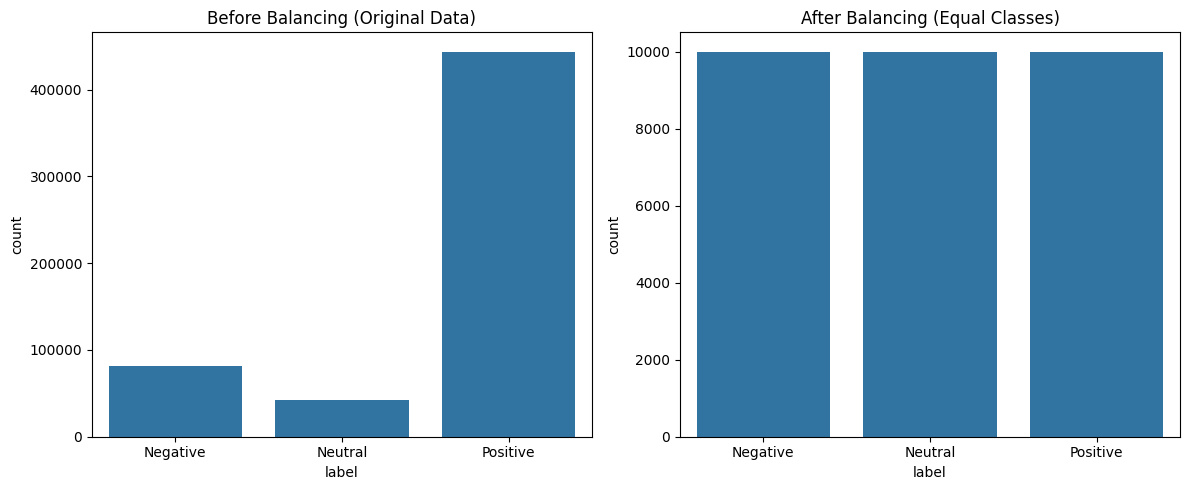

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# BEFORE (original dataset)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(x=df['label'])
plt.title("Before Balancing (Original Data)")
plt.xticks([0,1,2], ['Negative','Neutral','Positive'])

# AFTER (balanced dataset)
plt.subplot(1,2,2)
sns.countplot(x=df_balanced['label'])
plt.title("After Balancing (Equal Classes)")
plt.xticks([0,1,2], ['Negative','Neutral','Positive'])

plt.tight_layout()
plt.show()

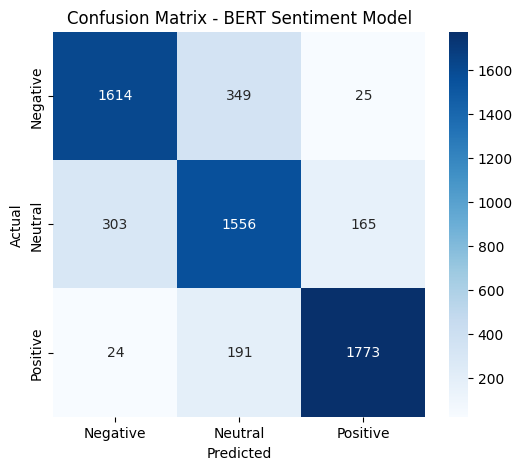

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
preds = trainer.predict(test_dataset)
y_true = preds.label_ids
y_pred = preds.predictions.argmax(axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

labels = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - BERT Sentiment Model')
plt.show()

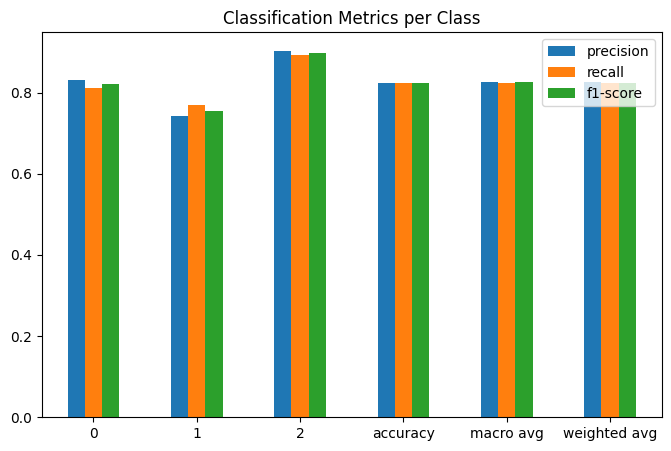

In [26]:
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report[['precision','recall','f1-score']].plot(kind='bar', figsize=(8,5))
plt.title("Classification Metrics per Class")
plt.xticks(rotation=0)
plt.show()

## 9. 🔮 Inference Demo

Predict the sentiment of a custom review text.

In [27]:
# ── Prediction helper function ────────────────────────────────────────────────
LABEL_MAP = {0: '😡 Negative', 1: '😐 Neutral', 2: '😊 Positive'}

def predict_sentiment(review_text: str) -> str:
    """
    Predict the sentiment of a given review string.

    Args:
        review_text: Raw review string.

    Returns:
        Sentiment label: 'Negative', 'Neutral', or 'Positive'.
    """
    # Put model in evaluation mode
    model.eval()

    # Tokenize the input
    inputs = tokenizer(
        review_text,
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=128
    )

    # Move tensors to the same device as the model
    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Forward pass (no gradient needed)
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predicted class index
    predicted_class = torch.argmax(outputs.logits, dim=-1).item()
    return LABEL_MAP[predicted_class]

In [28]:
# ── Test with sample reviews ──────────────────────────────────────────────────
sample_reviews = [
    "This product is absolutely amazing! Best purchase I've ever made. Totally worth every penny!",
    "It's okay I guess. Nothing special, nothing terrible. Just a very average product.",
    "Terrible quality. Broke after two days. Complete waste of money. Very disappointed."
]

print("🔮 Sentiment Predictions\n" + "=" * 50)
for review in sample_reviews:
    sentiment = predict_sentiment(review)
    print(f"\nReview   : {review[:80]}...")
    print(f"Sentiment: {sentiment}")

🔮 Sentiment Predictions

Review   : This product is absolutely amazing! Best purchase I've ever made. Totally worth ...
Sentiment: 😊 Positive

Review   : It's okay I guess. Nothing special, nothing terrible. Just a very average produc...
Sentiment: 😐 Neutral

Review   : Terrible quality. Broke after two days. Complete waste of money. Very disappoint...
Sentiment: 😡 Negative


In [29]:
# ── GUI: Interactive Sentiment Analysis (Gradio) ──────────────────────────────

# Install Gradio if not already installed
!pip install -q gradio

import gradio as gr

# Wrapper function (uses your existing model)
def analyze_review(review):
    if review.strip() == "":
        return "Please enter a review."
    
    prediction = predict_sentiment(review)
    return f"Predicted Sentiment: {prediction}"

# Build the interface
demo = gr.Interface(
    fn=analyze_review,
    inputs=gr.Textbox(
        lines=4,
        placeholder="Type your review here...",
        label="Enter Product Review"
    ),
    outputs=gr.Textbox(label="Model Prediction"),
    title="🛒 BERT Sentiment Analysis",
    description="Enter a product review and the model will predict whether it is Positive, Neutral, or Negative.",
    theme="soft"
)

# Launch the GUI
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://ca12bf4900890315b0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
## ✅ Summary

| Step | Details |
|------|---------|
| Dataset | Amazon Fine Food Reviews (~568k rows) |
| Balancing | 10,000 samples × 3 classes = 30,000 total |
| Model | `bert-base-uncased` (110M parameters) |
| Max Length | 128 tokens |
| Epochs | 5 |
| Batch Size | 16 (train & eval) |
| Labels | 0=Negative · 1=Neutral · 2=Positive |

The fine-tuned model can now be used as a **sentiment signal** to feed into the E-Commerce Recommendation pipeline.